(working-with-rag)=
# Working with RAG in MLRun

Learn how to build a RAG pipeline using MLRun from top to bottom, using popular models and frameworks.

**In this section**
- [Overview of RAG application and strategy](#overview-of-rag-application-and-strategy)
- [Prerequisite](#prerequisite)
- [Install a vector DB and dependencies](#install-a-vector-db-and-dependencies)
- [Setup](#setup)
- [Define OpenAI arguments](#define-openai-arguments)
- [Create a data indexing function](#create-a-data-indexing-function)
- [Index the dataset in the vector store](#index-the-dataset-in-the-vector-store)
- [Create a retrieval function](#create-a-retrieval-function)
- [Test locally](#test-locally)
- [Deploy to an endpoint](#deploy-to-an-endpoint)

## Overview of RAG application and strategy
Retrieval Augmented Generation (RAG) is a common strategy for extending the knowledge of pre-trained LLMs.<br>
It gives the LLM a corpus of knowledge to draw from when answering questions about topics, or information that was not in the original training set.

![](_static/rag_architecture.jpg)

### Parts of RAG architecture

There are a number of open source and proprietary embedding models, LLMs, and vector stores.<br>


- **Vector Store**: Used to store the embedded documents in a format that allows for semantic search and retrieval.<br>
    - This example uses [Milvus](https://milvus.io) &mdash; an open-source vector database designed specifically for similarity search on massive datasets of high-dimensional vectors.<br>
- **Embeddings Model**: Used to embed the documents, as well as embedding new user queries for semantic search.<br>
    - This example uses OpenAI's [text-embedding-3-small](https://platform.openai.com/docs/guides/embeddings).<br>
- **LLM**: used for generating responses.<br>
    - This example uses OpenAI's [gpt-3.5-turbo-0125](https://platform.openai.com/docs/models/gpt-3-5-turbo).<br>
    
## Prerequisite

In [25]:
# %pip install langchain langchain_community langchain_openai pymilvus langchain_huggingface "protobuf<3.20"

## Install a vector DB and dependencies

As mentioned above, this example uses [Milvus](https://milvus.io) -&mdash; an open-source vector database designed specifically for similarity search on massive datasets of high-dimensional vectors.<br>
It can be installed via [docker-compose](https://milvus.io/docs/v2.0.x/install_standalone-docker.md) or [Kubernetes](https://milvus.io/docs/v2.0.x/install_standalone-helm.md) depending on your MLRun installation method.<br>
In this example, Milvus is already installed in the Kubernetes cluster and the service is available at `http://milvus.default.svc.cluster.local:19530`.

## Setup

In [1]:
import os

# OpenAI
OPENAI_BASE_URL = ""
OPENAI_API_KEY = ""
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
os.environ["OPENAI_BASE_URL"] = OPENAI_BASE_URL
OPENAI_MODEL = "gpt-3.5-turbo-0125"

# Embeddings
EMBEDDINGS_MODEL = "all-MiniLM-L6-v2"

# Milvus dev deployment using helm:
# helm install my-milvus milvus/milvus --set cluster.enabled=false --set standalone.persistence.enabled=false --set etcd.replicaCount=1 --set minio.mode=standalone --set pulsar.enabled=false --set minio.persistence.enabled=false --set etcd.persistence.enabled=false

# Milvus
MILVUS_CONNECTION_ARGS = {
    "host": "my-milvus.default.svc.cluster.local",
    "port": "19530",
}

PROMPT_TEMPLATE = """Use the following pieces of context to answer the question at the end.
If you don't know the answer, just say that you don't know, don't try to make up an answer.
Use three sentences maximum and keep the answer as concise as possible.
Always say "thanks for asking!" at the end of the answer.

{context}

Question: {question}

Helpful Answer:"""

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [ ]:
import mlrun

project = mlrun.get_or_create_project("rag")

## Define OpenAI arguments

In [2]:
# Set embedding and model arguments
embeddings_class = "langchain_openai.embeddings.OpenAIEmbeddings"
embeddings_kwargs = {"model": "text-embedding-3-small"}
llm_class = "langchain_openai.chat_models.ChatOpenAI"
llm_kwargs = {"model": OPENAI_MODEL}

## Create a data indexing function

In [9]:
%%writefile index_data_new.py
import mlrun
from mlrun.utils import create_class
import pandas as pd
from langchain_community.vectorstores import Milvus
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import uuid

@mlrun.handler()
def index_urls(
    data: pd.DataFrame,
    url_column: str,
    embeddings_class: str,
    embeddings_kwargs: dict,
    milvus_host: str,
    milvus_port: int,
    chunk_size: int,
    chunk_overlap: int,
):  
    
    spec = mlrun.artifacts.DocumentLoaderSpec(loader_class_name="langchain_community.document_loaders.WebBaseLoader", 
                                              src_name="web_path",
                                              download_object =False)
    
    # Split documents
    text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap
        )
    
    project = mlrun.get_current_project()

    
    # Load embeddings and LLM models
    embeddings = create_class(embeddings_class)(**embeddings_kwargs)
    
    # Load vector store
    vector_db = Milvus(
        embedding_function=embeddings,
        connection_args={
            "host": milvus_host,
            "port": str(milvus_port),
        },
        auto_id=True
    )
    
    # Create MLRun collection wrapper
    collection = project.get_vector_store_collection(vector_store=vector_db)
    
    # Get input URLs
    urls = set(data[url_column].values)
        
    for doc in urls:
        
        artifact_key = mlrun.artifacts.DocumentArtifact.key_from_source(doc)
        
        artifact = project.log_document(key=artifact_key, 
                                        target_path=doc, 
                                        document_loader_spec=spec)
        
        milvus_ids = collection.add_artifacts([artifact], splitter=text_splitter)
        
        print("Documents added with IDs:", milvus_ids)

Overwriting index_data_new.py


## Index the dataset in the vector store

In [10]:
index_fn = project.set_function(
    name="index",
    func="index_data_new.py",
    kind="job",
    image="mlrun/mlrun",
    handler="index_urls",
)

index_fn.set_envs(
    {"OPENAI_API_KEY": OPENAI_API_KEY, "OPENAI_BASE_URL": OPENAI_BASE_URL}
)

In [11]:
# Create a dataset of files to use in RAG
data = pd.DataFrame(
    [
        {"url": "https://docs.mlrun.org/en/latest/index.html"},
        {"url": "https://docs.mlrun.org/en/latest/cheat-sheet.html"},
        {"url": "https://docs.mlrun.org/en/latest/tutorials/01-mlrun-basics.html"},
    ]
)
data

,url
0,https://docs.mlrun.org/en/latest/index.html
1,https://docs.mlrun.org/en/latest/cheat-sheet.html
2,https://docs.mlrun.org/en/latest/tutorials/01-...


In [12]:
# Log the dataset as an artifact
dataset_artifact = project.log_dataset(key="to-index", df=data)
dataset_artifact.uri

'store://datasets/rag/to-index#0@608179dd-88fa-4f22-9bf0-182c05487094^e91e1fcb0d50e5dcbfd27636132648929c5fb20a'

In [13]:
# Run the indexing function you wrote above
project.run_function(
    index_fn,
    inputs={"data": dataset_artifact.uri},
    params={
        "url_column": "url",
        "embeddings_class": embeddings_class,
        "embeddings_kwargs": embeddings_kwargs,
        "milvus_host": MILVUS_CONNECTION_ARGS["host"],
        "milvus_port": MILVUS_CONNECTION_ARGS["port"],
        "chunk_size": 2000,
        "chunk_overlap": 200,
    },
    local=True,
)

> 2025-01-21 06:58:25,118 [info] Storing function: {"db":"http://mlrun-api:8080","name":"index-index-urls","uid":"9c105c7feafb4fb6b60ac7c49c11fbe2"}
Documents added with IDs: [454873324101293747, 454873324101293748, 454873324101293749, 454873324101293750, 454873324101293751, 454873324101293752, 454873324101293753, 454873324101293754, 454873324101293755, 454873324101293756]
Documents added with IDs: [454873324101293758, 454873324101293759, 454873324101293760, 454873324101293761, 454873324101293762, 454873324101293763, 454873324101293764, 454873324101293765, 454873324101293766, 454873324101293767, 454873324101293768, 454873324101293769, 454873324101293770]
Documents added with IDs: [454873324101293772, 454873324101293773, 454873324101293774, 454873324101293775, 454873324101293776, 454873324101293777, 454873324101293778, 454873324101293779, 454873324101293780, 454873324101293781, 454873324101293782, 454873324101293783, 454873324101293784, 454873324101293785, 454873324101293786, 4548733241

project,uid,iter,start,state,kind,name,labels,inputs,parameters,results
rag,...9c11fbe2,0,Jan 21 06:58:25,completed,run,index-index-urls,v3io_user=edmondkind=localowner=edmondhost=jupyter-edmond-769c6b57f6-6xpgz,data,url_column=urlembeddings_class=langchain_openai.embeddings.OpenAIEmbeddingsembeddings_kwargs={'model': 'text-embedding-3-small'}milvus_host=my-milvus.default.svc.cluster.localmilvus_port=19530chunk_size=2000chunk_overlap=200,


> 2025-01-21 06:58:29,529 [info] Run execution finished: {"name":"index-index-urls","status":"completed"}


## Create a retrieval function

In [9]:
%%writefile retrieval_new.py
import mlrun
import os
from mlrun.serving.v2_serving import V2ModelServer
from typing import Dict, Any, Union
from langchain_core.language_models.llms import LLM
from mlrun.utils import create_class
from langchain_community.vectorstores import Milvus

class QueryMilvus:
    """ A class to query the Milvus vector store and retrieve relevant documents."""
    def __init__(
        self,
        project: str,
        embeddings_class: str,
        embeddings_kwargs: dict,
        milvus_connection_args: dict,
        num_documents: int = 3,
    ):
        self.project = mlrun.get_or_create_project(project, "./")
        self.embeddings_class = embeddings_class
        self.embeddings_kwargs = embeddings_kwargs
        self.embeddings = create_class(self.embeddings_class)(**self.embeddings_kwargs)
        self.milvus_connection_args = milvus_connection_args
        self.vector_db = Milvus(
            embedding_function=self.embeddings,
            connection_args=self.milvus_connection_args,
            auto_id=True
        )
        self.collection = self.project.get_vector_store_collection(vector_store=self.vector_db)
        self.num_documents = num_documents
        
    def do(self, event: dict):
        """
        The main function to query the Milvus vector store and retrieve relevant documents.
        """
        question = event["question"]
        num_documents = event.get("num_documents", self.num_documents)
        docs = self.collection.similarity_search(question, k=num_documents)
        event["context"] = "\n\n".join(doc.page_content for doc in docs)
        event["sources"] = list({doc.metadata["source"] for doc in docs})
        return event

    
class FormatPrompt:
    """ A class to format the prompt for the LLM model."""
    def __init__(self, prompt: str):
        self.prompt = prompt
        
    def do(self, event:dict):
        formatted_prompt = self.prompt.format(**event)
        event["inputs"] = [formatted_prompt]
        return event
    
        
class LangChainModelServer(mlrun.serving.V2ModelServer):
    """ A class to serve a LangChain model using MLRun serving."""
    def __init__(
        self,
        context: mlrun.MLClientCtx = None,
        model_class: str = None,
        llm: Union[str, LLM] = None,
        init_kwargs: Dict[str, Any] = None,
        generation_kwargs: Dict[str, Any] = None,
        name: str = None,
        model_path: str = None,
        **kwargs,
    ):
        """
        Initialize a serving class for general llm usage.
        :param model_class:      The class of the model to use.
        :param llm:              The name of specific llm to use, or the llm object itself in case of local usage.
        :param init_kwargs:      The initialization arguments to use while initializing the llm.
        :param generation_kwargs: The generation arguments to use while generating text.
        """
        super().__init__(
            name=name,
            context=context,
            model_path=model_path
        )
        self.model_class = model_class
        self.llm = llm
        self.init_kwargs = init_kwargs or {}
        self.generation_kwargs = generation_kwargs

    def load(self):
        # If the llm is already an LLM object, use it directly
        if isinstance(self.llm, LLM):
            self.model = self.llm
            return
        # If the llm is a string (or not given, then we take default model), load the llm from langchain.
        self.model = create_class(self.model_class)(**self.init_kwargs)

    def predict(self, request: Dict[str, Any], generation_kwargs: Dict[str, Any] = None):
        access_key = os.environ["V3IO_ACCESS_KEY"]
        headers = {"Cookie": 'session=j:{"sid": "' + access_key + '"}'}
        inputs = request.get("inputs", [])
        generation_kwargs = generation_kwargs or self.generation_kwargs        
        return self.model.invoke(input=inputs[0], 
                                 config=generation_kwargs, 
                                 headers=headers).dict()

Overwriting retrieval_new.py


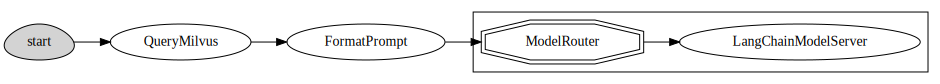

In [10]:
# Set the retrival function
rag_fn = project.set_function(
    name="rag",
    func="retrieval_new.py",
    kind="serving",
    image="gcr.io/iguazio/rag-deploy:1.0",
)

rag_fn.set_envs({"OPENAI_API_KEY": OPENAI_API_KEY, "OPENAI_BASE_URL": OPENAI_BASE_URL})

# Create the workflow and start connecting steps
graph = rag_fn.set_topology("flow", engine="async")

graph.add_step(
    class_name="QueryMilvus",
    project=project.name,
    embeddings_class=embeddings_class,
    embeddings_kwargs=embeddings_kwargs,
    milvus_connection_args=MILVUS_CONNECTION_ARGS,
)
graph.add_step(class_name="FormatPrompt", prompt=PROMPT_TEMPLATE, after="$prev")

router = graph.add_step(
    "*mlrun.serving.ModelRouter",
    name="ModelRouter",
    after="$prev",
    result_path="prediction",
).respond()
router.add_route(
    key="LangChainModelServer",
    class_name="LangChainModelServer",
    model_class=llm_class,
    init_kwargs=llm_kwargs,
    result_path="output",
    after="$prev",
)
graph.plot(rankdir="LR")

## Test locally

In [11]:
%%time
mock = rag_fn.to_mock_server()
resp = mock.test(
    path="/",
    body={"question": "Give me a python example of how to deploy a serving function"},
)

> 2024-12-29 10:07:45,136 [info] Project loaded successfully: {"project_name":"rag"}
> 2024-12-29 10:07:45,188 [info] model LangChainModelServer was loaded
> 2024-12-29 10:07:45,189 [info] Loaded ['LangChainModelServer']
{'Cookie': 'session=j:{"sid": "56167b0d-de03-4ba1-bc58-b9adf9d6a47b"}'}
CPU times: user 118 ms, sys: 49.8 ms, total: 168 ms
Wall time: 4.39 s


In [12]:
print(resp["prediction"]["outputs"]["content"])

Here is an example of how to deploy a serving function in Python:

```python
import mlrun

# Define the serving function
def main():
    # Create a project and set up the serving topology
    project = mlrun.serving.start_project()
    serving_fn = project.set_function(
        func="",
        name="serving",
        image="mlrun/mlrun",
        kind="serving",
        requirements=["scikit-learn~=1.5.1"],
    )

    # Add a model to the serving function
    serving_fn.add_model(
        "cancer-classifier",
        model_path="path/to/model",
        class_name="mlrun.frameworks.sklearn.SKLearnModelServer",
    )

    # Create a mock server and test the endpoint
    server = serving_fn.to_mock_server()
    server.test("/v2/models/", method="GET")
```

Thanks for asking!


In [14]:
print(resp["sources"])

['rag/2e588a01b0dc4806bf2b8592a047b0f2', 'rag/dad80a1867c74cf4aef40e3866362d71', 'rag/539a329744374d908bee3eb3d83ff8b8']


## Deploy to an endpoint

In [16]:
project.deploy_function(rag_fn)

> 2024-12-29 10:08:05,916 [info] Starting remote function deploy
2024-12-29 10:08:06  (info) Deploying function
2024-12-29 10:08:06  (info) Building
2024-12-29 10:08:06  (info) Staging files and preparing base images
2024-12-29 10:08:06  (warn) Using user provided base image, runtime interpreter version is provided by the base image
2024-12-29 10:08:06  (info) Building processor image
2024-12-29 10:11:11  (info) Build complete
2024-12-29 10:11:57  (info) Function deploy complete
> 2024-12-29 10:11:57,982 [info] Successfully deployed function: {"external_invocation_urls":["rag-rag.default-tenant.app.llm-3-6-0.iguazio-cd1.com/"],"internal_invocation_urls":["nuclio-rag-rag.default-tenant.svc.cluster.local:8080"]}


DeployStatus(state=ready, outputs={'endpoint': 'http://rag-rag.default-tenant.app.llm-3-6-0.iguazio-cd1.com/', 'name': 'rag-rag'})

In [17]:
%%time
resp2 = rag_fn.invoke(path="/", body={"question": "What is MLRun?"})

> 2024-12-29 10:12:05,853 [info] Invoking function: {"method":"POST","path":"http://nuclio-rag-rag.default-tenant.svc.cluster.local:8080/"}
CPU times: user 9 ms, sys: 90 µs, total: 9.09 ms
Wall time: 1.84 s


In [18]:
print(resp2["prediction"]["outputs"]["content"])

MLRun is an open-source Python framework for managing the lifecycle of machine learning models and applications. It provides a unified way to deploy, manage, and monitor machine learning models across different environments.

Thanks for asking!
